In [89]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, cheby1, cheby2, ellip, freqz

In [231]:
# Filterparameter

# Ordnung
order = 2
order_b = 1

# Abtastfrequenz für Audioanwendungen
fs = 44100

#Untere und obere Grenzen für Bandpass und Bandsperre
low = 500
high = 2000

# Grenzfrequenz für Tief- und Hochpass
fc = 1000 

# Ripple und Dämpung des Durchlass- und Sperrbereichs
rp = 1
rs = 80

# Normalisiert Grenzfrequenz
wn = fc / (fs/2)

# Normalisierte untere und obere Grenzfrequenz
wn_b = [low/(fs/2), high/(fs/2)]

In [233]:
# Butter Tiefpass Filterentwurf
b_lp_bw, a_lp_bw = butter(N=order,
                          Wn=wn,
                          btype='low',
                          analog=False)

# Frequenzgang berechnen
w_lp_bw, h_lp_bw = freqz(b_lp_bw, a_lp_bw, worN=1024, fs=fs)

# Koeffizienten
print('Butterworth-Tiefpass')
print('b Koeffizienten:', b_lp_bw)
print('a Koeffizienten:', a_lp_bw)

Butterworth-Tiefpass
b Koeffizienten: [0.004604 0.009208 0.004604]
a Koeffizienten: [ 1.         -1.79909641  0.8175124 ]


In [235]:
# Cheby1 Tiefpass Filterentwurf
b_lp_c1, a_lp_c1 = cheby1(N=order,
                          rp=rp,
                          Wn=wn,
                          btype='low',
                          analog=False)

# Frequenzgang berechnen
w_lp_c1, h_lp_c1 = freqz(b_lp_c1, a_lp_c1, worN=1024, fs=fs)

# Koeffizienten
print('Chebychev1-Tiefpass')
print('b Koeffizienten:', b_lp_c1)
print('a Koeffizienten:', a_lp_c1)

Chebychev1-Tiefpass
b Koeffizienten: [0.00461603 0.00923205 0.00461603]
a Koeffizienten: [ 1.         -1.83475026  0.85546733]


In [236]:
# Cheby2 Tiefpass Filterentwurf
b_lp_c2, a_lp_c2 = cheby2(N=order,
                          rs=rs,
                          Wn=wn,
                          btype='low',
                          analog=False)

# Frequenzgang berechnen
w_lp_c2, h_lp_c2 = freqz(b_lp_c2, a_lp_c2, worN=1024, fs=fs)

# Koeffizienten
print('Chebychev2-Tiefpass')
print('b Koeffizienten:', b_lp_c2)
print('a Koeffizienten:', a_lp_c2)

Chebychev2-Tiefpass
b Koeffizienten: [ 0.00010087 -0.00019768  0.00010087]
a Koeffizienten: [ 1.         -1.9971458   0.99714987]


In [239]:
# Ellip Tiefpass Filterentwurf
b_lp_ep, a_lp_ep = ellip(N=order,
                         rp=rp,
                         rs=rs,
                         Wn=wn,
                         btype='low',
                         analog=False)

# Frequenzgang berechnen
w_lp_ep, h_lp_ep = freqz(b_lp_ep, a_lp_ep, worN=1024, fs=fs)

# Koeffizienten
print('Elliptischer-Tiefpass')
print('b Koeffizienten:', b_lp_ep)
print('a Koeffizienten:', a_lp_ep)

Elliptischer-Tiefpass
b Koeffizienten: [0.00470853 0.00904805 0.00470853]
a Koeffizienten: [ 1.         -1.83475669  0.85547489]


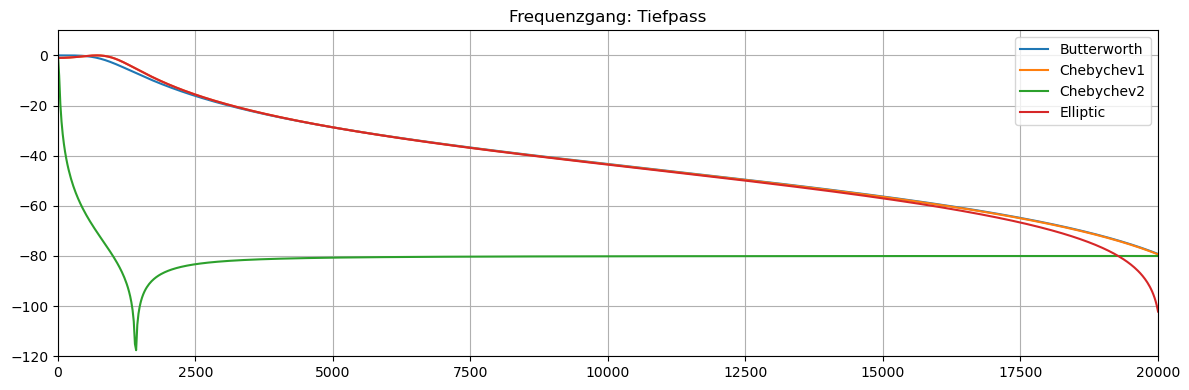

In [240]:
# Plot: Tiefpassvergleich
plt.figure(figsize= (12,4))
plt.plot(w_lp_bw, 20 * np.log10(np.maximum(np.abs(h_lp_bw),1e-10)), label='Butterworth')
plt.plot(w_lp_c1, 20 * np.log10(np.maximum(np.abs(h_lp_c1),1e-10)), label='Chebychev1')
plt.plot(w_lp_c2, 20 * np.log10(np.maximum(np.abs(h_lp_c2),1e-10)), label='Chebychev2')
plt.plot(w_lp_ep, 20 * np.log10(np.maximum(np.abs(h_lp_ep),1e-10)), label='Elliptic')
plt.title('Frequenzgang: Tiefpass')
plt.grid()
plt.xlim([0, 20000])
plt.ylim([-120, 10])
plt.legend()

plt.tight_layout()
plt.show()

In [242]:
# Butter Hochpass Filterentwurf
b_hp_bw, a_hp_bw = butter(N=order,
                          Wn=wn,
                          btype='high',
                          analog=False)

# Frequenzgang berechnen
w_hp_bw, h_hp_bw = freqz(b_hp_bw, a_hp_bw, worN=1024, fs=fs)

# Koeffizienten
print('Butterworth-Tiefpass')
print('b Koeffizienten:', b_hp_bw)
print('a Koeffizienten:', a_hp_bw)

Butterworth-Tiefpass
b Koeffizienten: [ 0.9041522  -1.80830441  0.9041522 ]
a Koeffizienten: [ 1.         -1.79909641  0.8175124 ]


In [243]:
# Cheby1 Hochpass Filterentwurf
b_hp_c1, a_hp_c1 = cheby1(N=order,
                          rp=rp,
                          Wn=wn,
                          btype='high',
                          analog=False)

# Frequenzgang berechnen
w_hp_c1, h_hp_c1 = freqz(b_hp_c1, a_hp_c1, worN=1024, fs=fs)

# Koeffizienten
print('Chebychev1-Hochpass')
print('b Koeffizienten:', b_hp_c1)
print('a Koeffizienten:', a_hp_c1)

Chebychev1-Hochpass
b Koeffizienten: [ 0.82855565 -1.6571113   0.82855565]
a Koeffizienten: [ 1.         -1.85072204  0.86789688]


In [244]:
# Cheby2 Hochpass Filterentwurf
b_hp_c2, a_hp_c2 = cheby2(N=order,
                          rs=rs,
                          Wn=wn,
                          btype='high',
                          analog=False)

# Frequenzgang berechnen
w_hp_c2, h_hp_c2 = freqz(b_hp_c2, a_hp_c2, worN=1024, fs=fs)

# Koeffizienten
print('Chebychev2-Hochpass')
print('b Koeffizienten:', b_hp_c2)
print('a Koeffizienten:', a_hp_c2)

Chebychev2-Hochpass
b Koeffizienten: [ 0.02984139 -0.05937965  0.02984139]
a Koeffizienten: [1.         1.45615188 0.57521431]


In [246]:
# Ellip Hochpass Filterentwurf
b_hp_ep, a_hp_ep = ellip(N=order,
                         rp=rp,
                         rs=rs,
                         Wn=wn,
                         btype='high',
                         analog=False)

# Frequenzgang berechnen
w_hp_ep, h_hp_ep = freqz(b_hp_ep, a_hp_ep, worN=1024, fs=fs)

# Koeffizienten
print('Elliptischer-Hochpass')
print('b Koeffizienten:', b_hp_ep)
print('a Koeffizienten:', a_hp_ep)

Elliptischer-Hochpass
b Koeffizienten: [ 0.82856212 -1.65712252  0.82856212]
a Koeffizienten: [ 1.         -1.85073596  0.86791005]


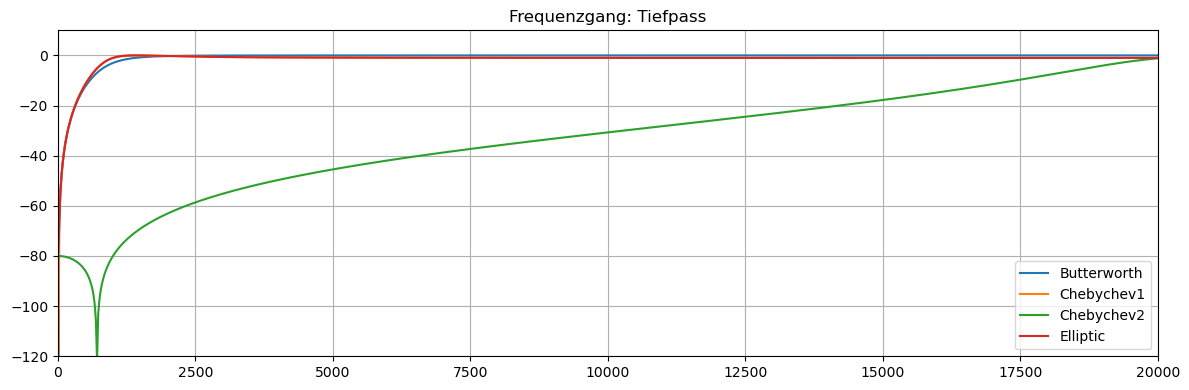

In [250]:
# Plot: Hochpassvergleich
plt.figure(figsize= (12,4))
plt.plot(w_hp_bw, 20 * np.log10(np.maximum(np.abs(h_hp_bw),1e-10)), label='Butterworth')
plt.plot(w_hp_c1, 20 * np.log10(np.maximum(np.abs(h_hp_c1),1e-10)), label='Chebychev1')
plt.plot(w_hp_c2, 20 * np.log10(np.maximum(np.abs(h_hp_c2),1e-10)), label='Chebychev2')
plt.plot(w_hp_ep, 20 * np.log10(np.maximum(np.abs(h_hp_ep),1e-10)), label='Elliptic')
plt.title('Frequenzgang: Tiefpass')
plt.grid()
plt.xlim([0, 20000])
plt.ylim([-120, 10])
plt.legend()

plt.tight_layout()
plt.show()

In [252]:
# Butter Bandpass Filterentwurf
b_bp_bw, a_bp_bw = butter(N=order_b,
                          Wn=wn_b,
                          btype='bandpass',
                          analog=False)

# Frequenzgang berechnen
w_bp_bw, h_bp_bw = freqz(b_bp_bw, a_bp_bw, worN=1024, fs=fs)

# Koeffizienten
print('Butterworth-Bandpass')
print('b Koeffizienten:', b_bp_bw)
print('a Koeffizienten:', a_bp_bw)

Butterworth-Bandpass
b Koeffizienten: [ 0.09687421  0.         -0.09687421]
a Koeffizienten: [ 1.         -1.78787973  0.80625157]


In [253]:
# Cheby1 Bandpass Filterentwurf
b_bp_c1, a_bp_c1 = cheby1(N=order_b,
                          rp=rp,
                          Wn=wn_b,
                          btype='bandpass',
                          analog=False)

# Frequenzgang berechnen
w_bp_c1, h_bp_c1 = freqz(b_bp_c1, a_bp_c1, worN=1024, fs=fs)

# Koeffizienten
print('Chebychev1-Bandpass')
print('b Koeffizienten:', b_bp_c1)
print('a Koeffizienten:', a_bp_c1)

Chebychev1-Bandpass
b Koeffizienten: [ 0.17410043  0.         -0.17410043]
a Koeffizienten: [ 1.         -1.63499827  0.65179914]


In [255]:
# Cheby2 Bandpass Filterentwurf
b_bp_c2, a_bp_c2 = cheby2(N=order_b,
                          rs=rs,
                          Wn=wn_b,
                          btype='bandpass',
                          analog=False)

# Frequenzgang berechnen
w_bp_c2, h_bp_c2 = freqz(b_bp_c2, a_bp_c2, worN=1024, fs=fs)

# Koeffizienten
print('Chebychev2-Bandpass')
print('b Koeffizienten:', b_bp_c2)
print('a Koeffizienten:', a_bp_c2)

Chebychev2-Bandpass
b Koeffizienten: [ 1.07264321e-05  0.00000000e+00 -1.07264321e-05]
a Koeffizienten: [ 1.         -1.97963625  0.99997855]


In [257]:
# Ellip Bandpass Filterentwurf
b_bp_ep, a_bp_ep = ellip(N=order_b,
                         rp=rp,
                         rs=rs,
                         Wn=wn_b,
                         btype='bandpass',
                         analog=False)

# Frequenzgang berechnen
w_bp_ep, h_bp_ep = freqz(b_bp_ep, a_bp_ep, worN=1024, fs=fs)

# Koeffizienten
print('Elliptischer-Bandstop')
print('b Koeffizienten:', b_bp_ep)
print('a Koeffizienten:', a_bp_ep)

Elliptischer-Bandstop
b Koeffizienten: [ 0.17410043  0.         -0.17410043]
a Koeffizienten: [ 1.         -1.63499827  0.65179914]


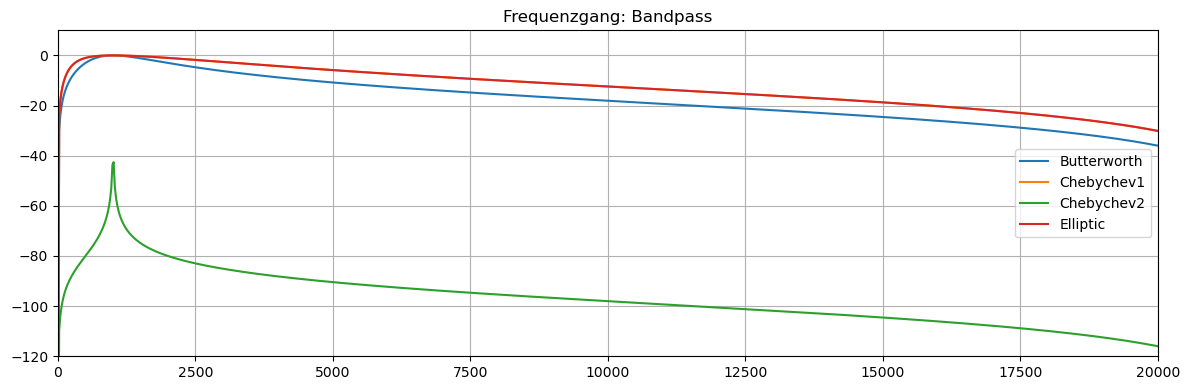

In [260]:
# Plot: Bandpassvergleich
plt.figure(figsize= (12,4))
plt.plot(w_bp_bw, 20 * np.log10(np.maximum(np.abs(h_bp_bw),1e-10)), label='Butterworth')
plt.plot(w_bp_c1, 20 * np.log10(np.maximum(np.abs(h_bp_c1),1e-10)), label='Chebychev1')
plt.plot(w_bp_c2, 20 * np.log10(np.maximum(np.abs(h_bp_c2),1e-10)), label='Chebychev2')
plt.plot(w_bp_ep, 20 * np.log10(np.maximum(np.abs(h_bp_ep),1e-10)), label='Elliptic')
plt.title('Frequenzgang: Bandpass')
plt.grid()
plt.xlim([0, 20000])
plt.ylim([-120, 10])
plt.legend()

plt.tight_layout()
plt.show()

In [262]:
# Butter Bandstop Filterentwurf
b_bs_bw, a_bs_bw = butter(N=order_b,
                          Wn=wn_b,
                          btype='bandstop',
                          analog=False)

# Frequenzgang berechnen
w_bs_bw, h_bs_bw = freqz(b_bs_bw, a_bs_bw, worN=1024, fs=fs)

# Koeffizienten
print('Butterworth-Bandstop')
print('b Koeffizienten:', b_bs_bw)
print('a Koeffizienten:', a_bs_bw)

Butterworth-Bandstop
b Koeffizienten: [ 0.90312579 -1.78787973  0.90312579]
a Koeffizienten: [ 1.         -1.78787973  0.80625157]


In [263]:
# Cheby1 Bandstop Filterentwurf
b_bs_c1, a_bs_c1 = cheby1(N=order_b,
                          rp=rp,
                          Wn=wn_b,
                          btype='bandstop',
                          analog=False)

# Frequenzgang berechnen
w_bs_c1, h_bs_c1 = freqz(b_bs_c1, a_bs_c1, worN=1024, fs=fs)

# Koeffizienten
print('Chebychev1-Bandstop')
print('b Koeffizienten:', b_bs_c1)
print('a Koeffizienten:', a_bs_c1)

Chebychev1-Bandstop
b Koeffizienten: [ 0.94824325 -1.87719684  0.94824325]
a Koeffizienten: [ 1.         -1.87719684  0.89648649]


In [264]:
# Cheby2 Bandstop Filterentwurf
b_bs_c2, a_bs_c2 = cheby2(N=1,
                          rs=rs,
                          Wn=wn_b,
                          btype='bandstop',
                          analog=False)

# Frequenzgang berechnen
w_bs_c2, h_bs_c2 = freqz(b_bs_c2, a_bs_c2, worN=1024, fs=fs)

# Koeffizienten
print('Chebychev2-Bandstop')
print('b Koeffizienten:', b_bs_c2)
print('a Koeffizienten:', a_bs_c2)

Chebychev2-Bandstop
b Koeffizienten: [ 0.0009314  -0.00184385  0.0009314 ]
a Koeffizienten: [ 1.         -0.00184385 -0.9981372 ]


In [265]:
# Ellip Bandstop Filterentwurf
b_bs_ep, a_bs_ep = ellip(N=order_b,
                         rp=rp,
                         rs=rs,
                         Wn=wn_b,
                         btype='bandstop',
                         analog=False)

# Frequenzgang berechnen
w_bs_ep, h_bs_ep = freqz(b_bs_ep, a_bs_ep, worN=1024, fs=fs)

# Koeffizienten
print('Elliptischer-Bandstop')
print('b Koeffizienten:', b_bs_ep)
print('a Koeffizienten:', a_bs_ep)

Elliptischer-Bandstop
b Koeffizienten: [ 0.94824325 -1.87719684  0.94824325]
a Koeffizienten: [ 1.         -1.87719684  0.89648649]


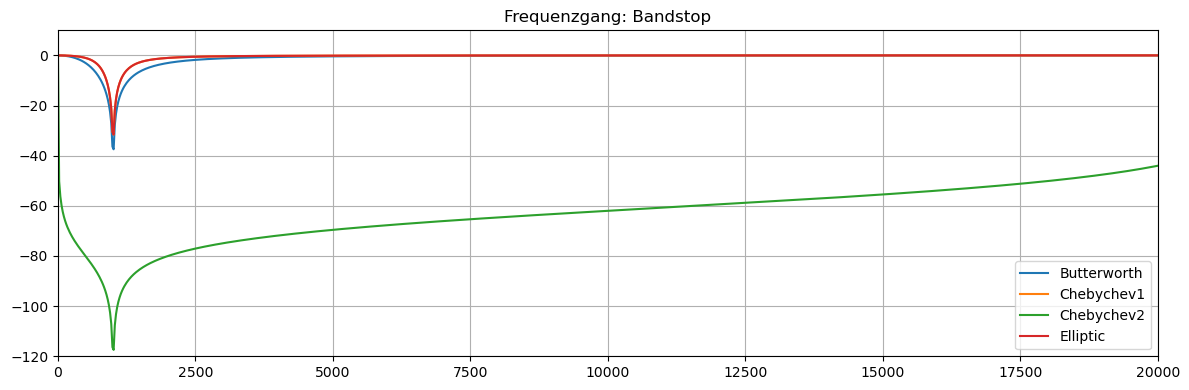

In [266]:
# Plot: Bandstopvergleich
plt.figure(figsize= (12,4))
plt.plot(w_bs_bw, 20 * np.log10(np.maximum(np.abs(h_bs_bw),1e-10)), label='Butterworth')
plt.plot(w_bs_c1, 20 * np.log10(np.maximum(np.abs(h_bs_c1),1e-10)), label='Chebychev1')
plt.plot(w_bs_c2, 20 * np.log10(np.maximum(np.abs(h_bs_c2),1e-10)), label='Chebychev2')
plt.plot(w_bs_ep, 20 * np.log10(np.maximum(np.abs(h_bs_ep),1e-10)), label='Elliptic')
plt.title('Frequenzgang: Bandstop')
plt.grid()
plt.xlim([0, 20000])
plt.ylim([-120, 10])
plt.legend()

plt.tight_layout()
plt.show()